# 💬 Sentiment Analysis Project

#### 🎯 1. Defining the Business Problem

This project begins by defining the **business problem** that needs to be solved.  
In Data Science, this step is extremely important because it connects **business needs** with **data-driven solutions**.

Before building any model, we need to clearly understand:

- ❓ **What problem we want to solve**
- 💡 **Why this problem matters for the company**
- 📏 **How success will be measured**

---

#### 🏢 Business Context

An **e-commerce company** receives thousands of product reviews from customers every day.

Currently, the analysis of these reviews is done **manually**, which creates several challenges:

- ⏳ **Slow analysis process**
- 💰 **High operational cost**
- 📈 **Difficulty scaling with the growing number of reviews**

Because of this, valuable customer feedback may take too long to be identified, making it harder for the company to react quickly to problems or opportunities.

---

#### 🎯 Project Objective

The goal of this project is to build a **Machine Learning model** capable of automatically classifying customer reviews into two categories:

- 😊 **Positive**
- 😡 **Negative**

By automating this process, the company will be able to analyze customer sentiment **faster, cheaper, and at scale**.

---

#### 🚀 Expected Business Benefits

**⚡ Efficiency**  
Reduce the time and cost associated with manual review analysis.

**📊 Faster Decision-Making**  
Enable product and marketing teams to quickly identify products with issues or opportunities for improvement.

**🎯 Better Prioritization**  
Automatically route **negative reviews** to the customer support team, allowing faster responses and improving the overall customer experience.

---

#### 📌 Introduction

Customer feedback is one of the most valuable sources of information for companies.  
However, when the volume of reviews grows significantly, manual analysis becomes inefficient and difficult to scale.

In this project, we apply **Natural Language Processing (NLP)** and **Machine Learning** techniques to build a **Sentiment Analysis model** capable of automatically classifying customer reviews as **positive** or **negative**.

This approach allows companies to **extract insights from large volumes of text data**, improving decision-making, operational efficiency, and customer satisfaction.

### 📥 Loading the Dataset and Libraries

Before we start, we need to install the necessary Python libraries and **load the dataset**.


In [1]:
# Install the required libraries
%pip install pandas numpy matplotlib seaborn scikit-learn -q 
# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data manipulation and visualization
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pre-Processing and Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
# Load the watermark extension
%reload_ext watermark

# Display metadata for your notebook
%watermark -a "Maykon - 💬 Sentiment Analysis Project" -d -u -v -p numpy,pandas,matplotlib,seaborn

Author: Maykon - 💬 Sentiment Analysis Project

Last updated: 2026-03-03

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.10.0

numpy     : 2.4.2
pandas    : 3.0.1
matplotlib: 3.10.8
seaborn   : 0.13.2



In [4]:
# Load the Sentiment Analysis dataset from a local CSV file into a pandas DataFrame
data = r"data\dataset.csv"

df = pd.read_csv(data)

In [5]:
# It returns the dimensions of the DataFrame as a tuple
df.shape

(500, 3)

In [6]:
df.head() #Displays the first rows of the DataFrame df.

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [7]:
df.sample(15) # Random 15 rows

,review_id,texto_review,sentimento
179,180,A embalagem do fone de ouvido chegou um pouco ...,positivo
107,108,A embalagem do monitor chegou um pouco amassad...,positivo
158,159,O teclado é horrível. O suporte ao cliente foi...,negativo
401,402,Odiei o livro. Qualidade frágil e veio com def...,negativo
35,36,Odiei o monitor. Qualidade horrível e veio com...,negativo
398,399,Amei o monitor! A qualidade é muito boa e a en...,positivo
125,126,AMEI O CADEIRA GAMER! A QUALIDADE É ÓTIMA E A ...,positivo
376,377,O fone de ouvido é péssima. O suporte ao clien...,negativo
345,346,Ótimo custo-benefício. O celular é fantástica ...,positivo
67,68,Péssima experiência. O livro quebrou no primei...,negativo


In [8]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


#### 4. 🔎📊 Exploratory Data Analysis (EDA)

The investigation phase Here, we dive into the data to uncover patterns, anomalies, and valuable insights 💡. We use graphs 📈 (such as comparing positive 😊 vs. negative 😠 sentiment) and statistical measures to better understand the distribution and characteristics of the data before making any modifications 🛠️.

In [9]:
# Information about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     500 non-null    int64
 1   texto_review  488 non-null    str  
 2   sentimento    500 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.8 KB


In [10]:
df.describe(include='all').T  # Generates descriptive statistics for all numeric columns in your DataFrame.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
texto_review,488,283,Estou muito frustrado com esta compra. Dinheir...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentimento,500,2,positivo,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Check for missing values on the DataFrame:

In [11]:
df.isna().sum()  # You can also use df.isnull().sum() — both do the same thing

review_id        0
texto_review    12
sentimento       0
dtype: int64


Distribution of Sentiments:



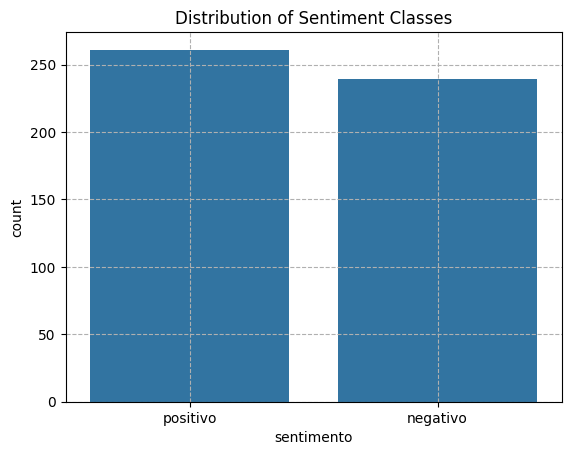

In [12]:
print("\nDistribution of Sentiments:\n")
sns.countplot(data = df, x = 'sentimento')
plt.title('Distribution of Sentiment Classes')
plt.grid(True, linestyle="--")
plt.show()

#### 5. 🧹 Data Cleaning

In this step, we correct the problems identified in the EDA 🔎. This includes handling missing values (e.g., removing the corresponding rows) 🗑️, ensuring that the data is in the correct format 📂, and applying the text cleaning function (dsa_clean_text) 🧼 to normalize the reviews ✍️ — removing accents, possible unwanted characters, and other noise characters 🚫.

In [ ]:
# Remove rows with missing values
print(f"\nOriginal DataFrame size: {len(df)}")
df.dropna(subset = ['texto_review'], inplace = True)
dfc = df.copy() # It creates a deep copy of your DataFrame for precaution.
print(f"DataFrame size after removing nulls: {len(dfc)}")


Original DataFrame size: 500
DataFrame size after removing nulls: 488


In [15]:
# It returns the dimensions of the DataFrame as a tuple
dfc.shape

(488, 3)

In [16]:
dfc.head() #Displays the first rows of the DataFrame df.

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [19]:
import re
import unicodedata

# Text Cleaning Function
def clean_text(text):
    """
    Complete text cleaning function:

    1. Convert to lowercase.
    2. Remove accents and cedillas.
    3. Remove numbers and special characters.
    4. Remove extra spaces.
    """

    # Ensure the text is a valid string (handle NaN or non-string values)
    if not isinstance(text, str):
        return ""

    # --- STEP 1: Normalize and remove accents ---
    text_without_accents = ''.join(
        c for c in unicodedata.normalize('NFKD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # --- STEP 2: Cleaning with Regex ---
    clean_text = text_without_accents.lower()

    # Keep only letters and spaces
    clean_text = re.sub(r'[^a-z\s]', '', clean_text)

    # Remove extra spaces
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()

    return clean_text

# created by ChatGPT

In [20]:
#Apply the cleaning function
dfc['texto_limpo'] = dfc['texto_review'].apply(clean_text) 

In [21]:
dfc.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


#### 6. ⚙️ Feature Engineering

This is the stage where we transform raw data into useful features for the model 🔄. In this project, this involves creating the clean_text column 🧼 and, more importantly, converting the text classes ('positive', 'negative') into a numerical format 🔢 (sentiment_label: 1, 0), which is what the Machine Learning algorithm can understand 🤖📊.

In [22]:
dfc.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


In [23]:
# Mapping sentiment to numerical values ​​(Attribute Engineering)
dfc['sentiment_label'] = dfc['sentimento'].map({'positive': 1, 'negative': 0})

In [28]:
print("\nDataFrame after cleaning and mapping:\n")
dfc[['texto_limpo', 'sentiment_label']].head()


DataFrame after cleaning and mapping:



,texto_limpo,sentiment_label
0,estou muito feliz com a compra o cadeira gamer...,NaN
2,nao recomendo a entrega foi lenta e o celular ...,NaN
3,o monitor e decepcionante o suporte ao cliente...,NaN
4,e um livro ok pelo prceo que paguei,NaN
5,nao rceomendo a entrega atrasou muito e o moni...,NaN


#### 7. 📊 Separating Data into Training and Test Sets

An essential step for training and evaluating the model. We split the dataset into two parts: a larger training set, which the model uses to learn patterns, and a smaller test set, which is kept "hidden" from the model to simulate new data and evaluate its real performance after training 📈🤖.